# STATE train/val loss curves — merfish only

One figure for merfish showing every available size. Each size gets a row with **train (left)** and **val (right)** on linear axes; viridis color encodes quality.

Pipeline:
1. **Loader** — walk `merfish/{size}/{quality}/results/State/model/loss/metrics.csv` and load train/val curves.
2. **Plot** — rows = sizes, columns = {train, val}, one viridis-colored line per quality.

Note: filename follows the `YYYY-MM-DD_HH-MM_plotting_<desc>.ipynb` convention from the project CLAUDE.md (not `compute_` — that prefix is reserved for `.py` scripts).

In [1]:
from pathlib import Path
import pandas as pd

DATA_ROOT = Path('/home/igor/noise_scaling/data')
DATASET = 'merfish'
ES_PATIENCE = 5  # matches scaling_laws.algo.state.State._save_final_losses

REQUIRED_COLS = {'step', 'trainer/train_loss', 'validation/val_loss'}


def _is_size_dir(p: Path) -> bool:
    return p.is_dir() and p.name.isdigit()


def _is_quality_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    try:
        float(p.name); return True
    except ValueError:
        return False


def _detect_es(val: pd.DataFrame, patience: int) -> tuple[bool, int]:
    if val.empty:
        return False, 0
    bidx = val['validation/val_loss'].idxmin()
    n_after = len(val) - 1 - bidx
    return (n_after >= patience), n_after


def _find_metrics_csv(state_model_dir: Path) -> Path | None:
    """Return a Lightning metrics.csv for this State run, or None.

    Checks both storage locations used by ``scaling_laws.algo.state.State``:
      1. ``model/loss/metrics.csv`` — copy written at end of training (finally).
      2. ``model/checkpoints/state_*/version_*/metrics.csv`` — Lightning's live file
         (exists mid-training too, useful for in-progress inspection).

    Prefers any CSV that has the full (step + both loss) schema; falls back to
    a CSV that at least has a ``step`` column so partial runs still show up.
    """
    candidates = []
    direct = state_model_dir / 'loss' / 'metrics.csv'
    if direct.exists():
        candidates.append(direct)
    ckpt_dir = state_model_dir / 'checkpoints'
    if ckpt_dir.is_dir():
        candidates.extend(ckpt_dir.glob('state_*/version_*/metrics.csv'))

    best_partial: Path | None = None
    for csv in candidates:
        if not csv.exists() or csv.stat().st_size == 0:
            continue
        try:
            cols = set(pd.read_csv(csv, nrows=0).columns)
        except Exception:
            continue
        if REQUIRED_COLS.issubset(cols):
            return csv  # complete — prefer immediately
        if best_partial is None and 'step' in cols:
            best_partial = csv
    return best_partial


def _read_scalar(path: Path) -> float | None:
    if not path.exists():
        return None
    try:
        return float(path.read_text().strip())
    except Exception:
        return None


ds_dir = DATA_ROOT / DATASET
assert ds_dir.is_dir(), f'{ds_dir} missing'

# curves[size][quality] -> dict with train/val frames + metadata (for plotting)
curves: dict[int, dict[float, dict]] = {}
# Tidy per-(size, quality) summary rows (for `results_df`).
summary_rows: list[dict] = []

print(f'{"size":>9}  {"quality":>10}  {"steps":>7}  {"epochs":>6}  '
      f'{"val_pts":>7}  {"best_step":>9}  {"best_val":>8}  {"after":>5}  '
      f'{"early_stop":>10}  {"src":>5}')
print('-' * 108)
for size_dir in sorted(filter(_is_size_dir, ds_dir.iterdir()), key=lambda p: int(p.name)):
    size = int(size_dir.name)
    size_bucket: dict[float, dict] = {}
    for q_dir in sorted(filter(_is_quality_dir, size_dir.iterdir()), key=lambda p: float(p.name)):
        q = float(q_dir.name)
        model_dir = q_dir / 'results' / 'State' / 'model'
        csv = _find_metrics_csv(model_dir)
        train_loss_txt = _read_scalar(model_dir / 'train_loss.txt')
        val_loss_txt   = _read_scalar(model_dir / 'val_loss.txt')
        test_loss_txt  = _read_scalar(model_dir / 'test_loss.txt')

        row = {
            'size': size, 'quality': q,
            'metrics_csv': str(csv) if csv else None,
            'csv_src': None,
            'n_train_pts': 0, 'n_val_pts': 0,
            'total_steps': 0, 'epoch_max': -1,
            'best_step': None, 'best_val': None,
            'final_train': None,
            'early_stopped': False, 'n_after_best': 0,
            'train_loss_txt': train_loss_txt,
            'val_loss_txt':   val_loss_txt,
            'test_loss_txt':  test_loss_txt,
        }

        if csv is None:
            summary_rows.append(row)
            continue
        row['csv_src'] = 'loss' if csv.parent.name == 'loss' else 'ckpt'

        try:
            df = pd.read_csv(csv, on_bad_lines='skip')
        except Exception:
            summary_rows.append(row)
            continue
        if 'validation/val_loss' not in df.columns or 'trainer/train_loss' not in df.columns:
            summary_rows.append(row)
            continue

        train = df[['step', 'trainer/train_loss']].dropna(subset=['trainer/train_loss']).reset_index(drop=True)
        val   = df[['step', 'validation/val_loss']].dropna(subset=['validation/val_loss']).reset_index(drop=True)
        if train.empty:
            summary_rows.append(row)
            continue

        epoch_max = int(df['epoch'].max()) if 'epoch' in df.columns and df['epoch'].notna().any() else -1
        total_steps = int(df['step'].max()) if 'step' in df.columns and not df.empty else 0
        final_train = float(train['trainer/train_loss'].iloc[-1])

        best_step, best_val, es, n_after = None, None, False, 0
        if not val.empty:
            bidx = val['validation/val_loss'].idxmin()
            best_step = int(val.iloc[bidx]['step'])
            best_val  = float(val.iloc[bidx]['validation/val_loss'])
            es, n_after = _detect_es(val, ES_PATIENCE)
            size_bucket[q] = {
                'train': train, 'val': val,
                'best_step': best_step, 'best_val': best_val,
                'es_triggered': es, 'n_after_best': n_after,
                'epoch_max': epoch_max, 'total_steps': total_steps,
                'csv': csv,
            }

        row.update({
            'n_train_pts': len(train), 'n_val_pts': len(val),
            'total_steps': total_steps, 'epoch_max': epoch_max,
            'best_step': best_step, 'best_val': best_val,
            'final_train': final_train,
            'early_stopped': es, 'n_after_best': n_after,
        })
        summary_rows.append(row)
        print(f'{size:>9d}  {q:>10g}  {total_steps:>7d}  {epoch_max:>6d}  '
              f'{len(val):>7d}  {str(best_step):>9s}  '
              f'{(f"{best_val:.4f}" if best_val is not None else "—"):>8s}  '
              f'{n_after:>5d}  {("YES" if es else "no"):>10}  {row["csv_src"]:>5}')
    if size_bucket:
        curves[size] = size_bucket

results_df = pd.DataFrame(summary_rows).sort_values(['size', 'quality']).reset_index(drop=True)
total_runs = sum(len(q) for q in curves.values())
n_complete = int(results_df['best_val'].notna().sum())
n_partial  = int((results_df['metrics_csv'].notna() & results_df['best_val'].isna()).sum())
n_missing  = int(results_df['metrics_csv'].isna().sum())
print(f'\nLoaded plottable curves for {total_runs} merfish runs across {len(curves)} sizes.')
print(f'`results_df`: {len(results_df)} rows  '
      f'(complete={n_complete}, partial/no-val={n_partial}, missing-csv={n_missing}).')

     size     quality    steps  epochs  val_pts  best_step  best_val  after  early_stop    src
------------------------------------------------------------------------------------------------------------
      100    0.027248     3999    1999        4        999   16.4000      3          no   loss
      100   0.0406617     3999    1999        4        999   18.2681      3          no   loss
      100   0.0606789     3999    1999        4        999   20.3077      3          no   loss
      100   0.0905502     3999    1999        4        999   23.6516      3          no   loss
      100    0.135127     3999    1999        4        999   26.6577      3          no   loss
      100    0.201648     3999    1999        4        999   29.2005      3          no   loss
      100    0.300916     3999    1999        4        999   31.1769      3          no   loss
      100    0.449052     4999    2499        5       1999   27.7941      3          no   loss
      100    0.670113     4999    24

## One row per size — train (left) + val (right)

Rows = every merfish size with loss curves on disk. Each row shows **train loss** (left) and **val loss** (right) on linear axes; viridis color encodes quality (log scale).

**`X` marker = best (minimum) validation loss** — plotted on the val panel at `(best_step, best_val)`. Same color as the quality it belongs to, black outline for visibility. This is the checkpoint that would be selected by `ModelCheckpoint(monitor='validation/val_loss', save_top_k=1)` and the value written to `model/val_loss.txt` / `model/test_loss.txt`.

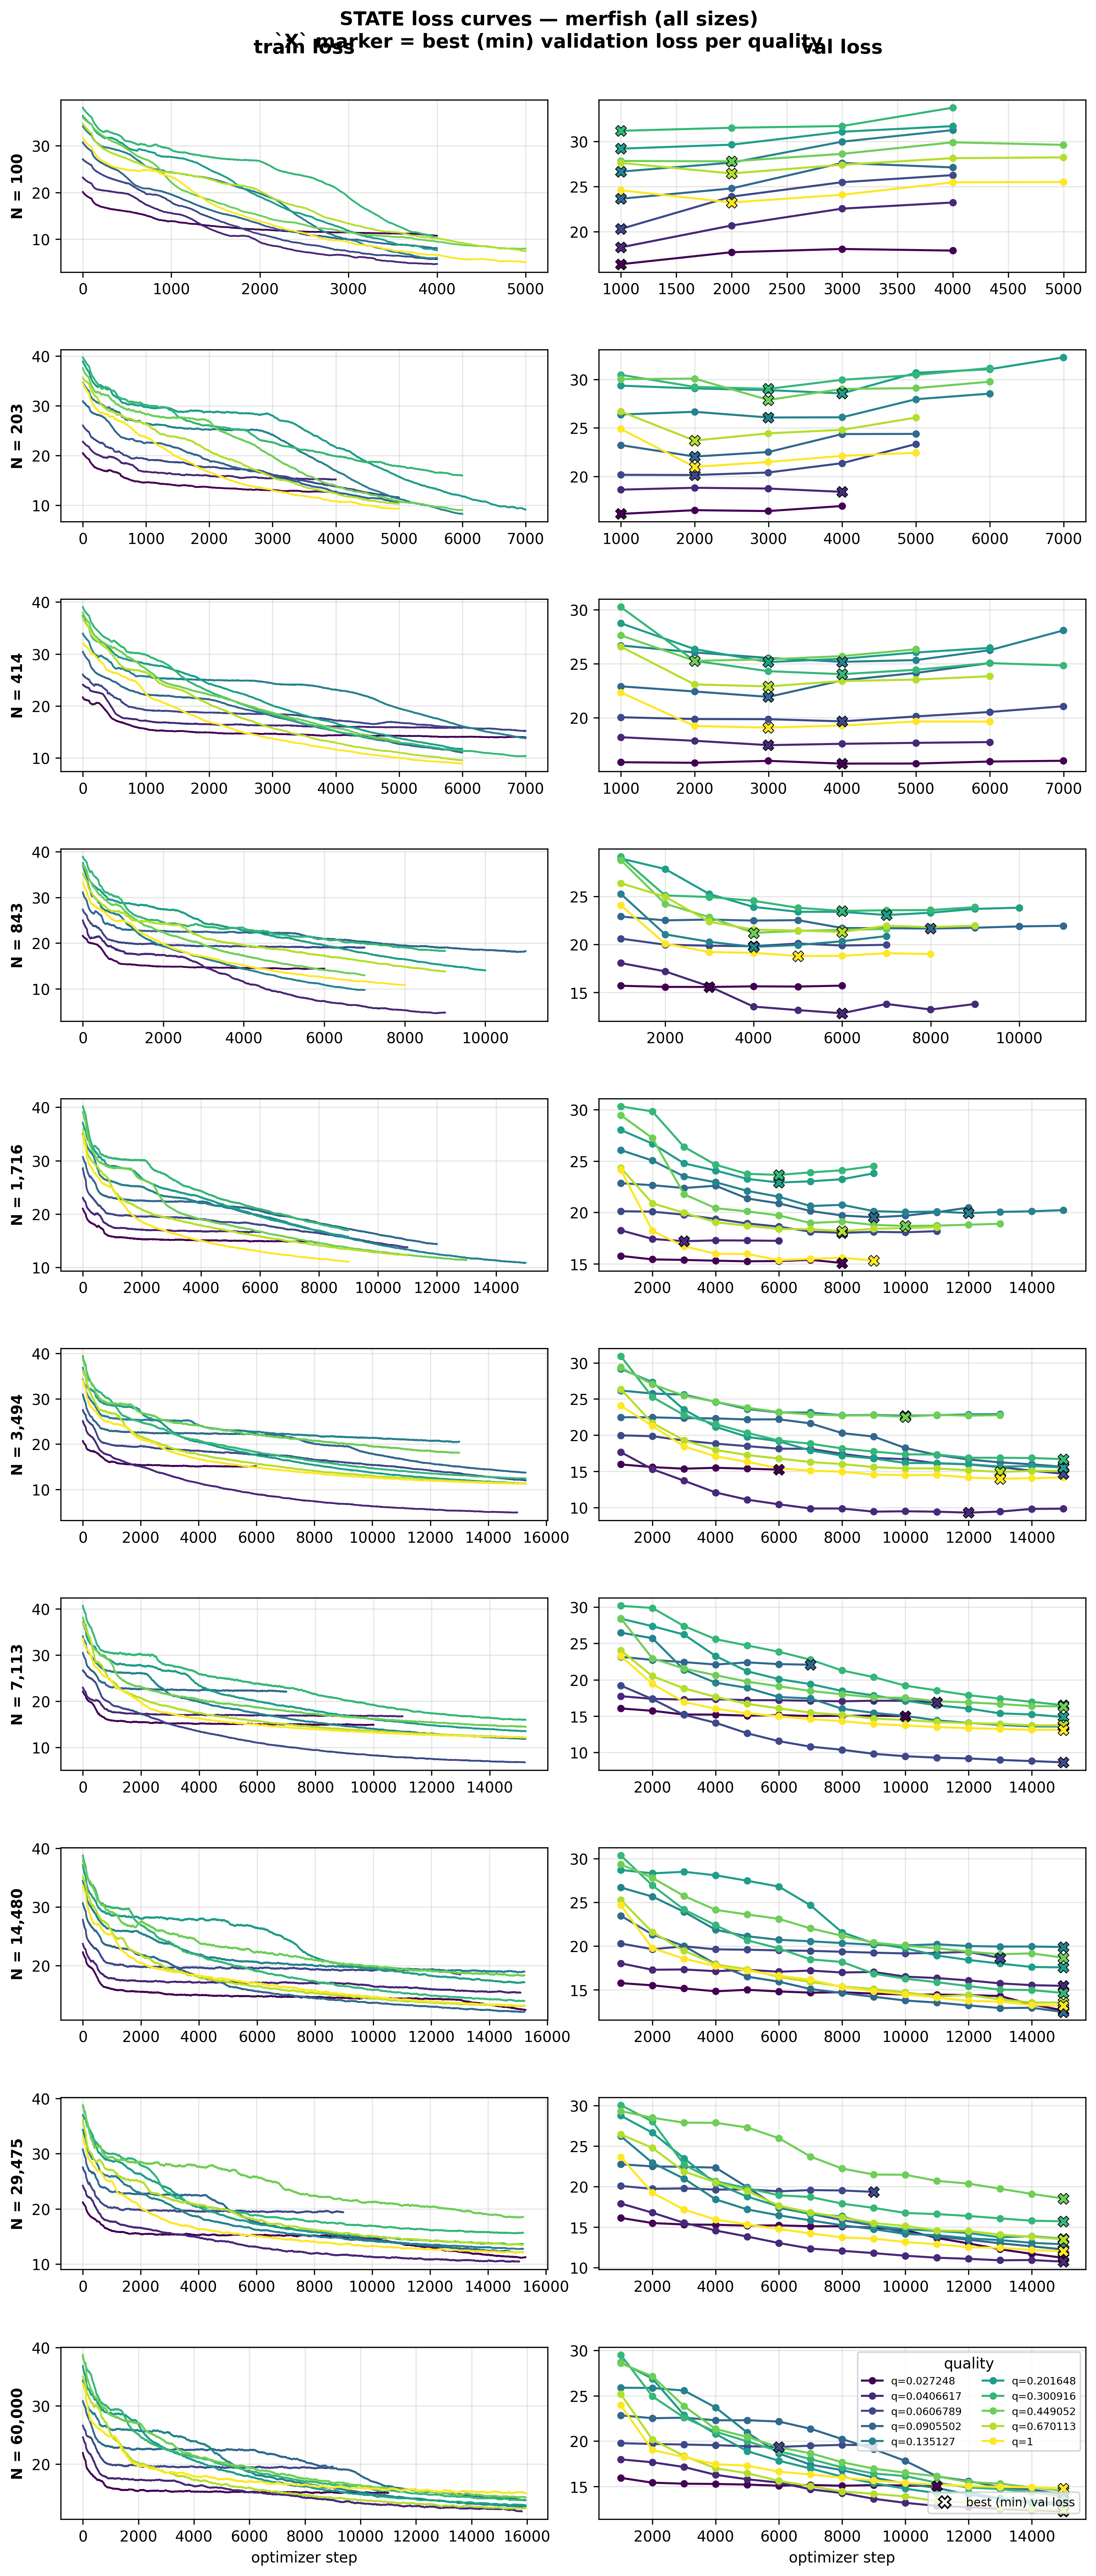

In [2]:
# Rows = sizes (ascending), columns = {train, val}.
# `X` marker on the val panel = best (minimum) validation loss for that quality
# (the checkpoint that would be saved by ModelCheckpoint with save_top_k=1).
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

sizes = sorted(curves.keys())
nrows = len(sizes)
ncols = 2  # train | val

PER_ROW_H = 2.4
FIG_DPI = 300
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5.2 * ncols, PER_ROW_H * nrows),
    dpi=FIG_DPI, squeeze=False,
)
cmap = plt.get_cmap('viridis')

for col, name in enumerate(['train loss', 'val loss']):
    axes[0, col].annotate(
        name, xy=(0.5, 1.25), xycoords='axes fraction',
        ha='center', va='bottom', fontsize=13, fontweight='bold',
    )

for row, size in enumerate(sizes):
    ax_t, ax_v = axes[row, 0], axes[row, 1]
    qmap = curves[size]
    qs = sorted(qmap.keys())
    norm = (plt.Normalize(np.log10(min(qs)), np.log10(max(qs)))
            if len(qs) > 1 else plt.Normalize(0, 1))
    for q in qs:
        info = qmap[q]
        color = cmap(norm(np.log10(q))) if len(qs) > 1 else cmap(0.5)
        train_pos = info['train'][info['train']['step'] > 0]
        val_pos   = info['val'][info['val']['step'] > 0]
        smooth = train_pos['trainer/train_loss'].rolling(
            window=200, min_periods=10, center=True).mean()
        ax_t.plot(train_pos['step'], smooth, color=color, linewidth=1.2, label=f'q={q:g}')
        ax_v.plot(val_pos['step'], val_pos['validation/val_loss'],
                  color=color, marker='o', linewidth=1.4, markersize=4, label=f'q={q:g}')
        ax_v.scatter([info['best_step']], [info['best_val']],
                     color=color, marker='X', s=55, edgecolor='k', linewidth=0.5, zorder=5)
    for ax in (ax_t, ax_v):
        ax.grid(alpha=0.3)
    ax_t.set_ylabel(f'N = {size:,}', fontsize=10, fontweight='bold')
    if row == nrows - 1:
        ax_t.set_xlabel('optimizer step')
        ax_v.set_xlabel('optimizer step')
    # Two legends on the last row: one for qualities, one explaining `X`.
    if row == nrows - 1:
        quality_legend = ax_v.legend(loc='upper right', fontsize=7, ncol=2, title='quality')
        ax_v.add_artist(quality_legend)
        best_marker = mlines.Line2D(
            [], [], color='k', marker='X', markersize=8,
            markerfacecolor='white', markeredgecolor='k',
            linestyle='None', label='best (min) val loss',
        )
        ax_v.legend(handles=[best_marker], loc='lower right',
                    fontsize=8, frameon=True)

plt.suptitle('STATE loss curves — merfish (all sizes)\n'
             "`X` marker = best (min) validation loss per quality",
             y=1.005, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.97, hspace=0.45)
plt.show()

## MI vs quality — merfish only

Collect MI estimates for every (size, quality, algorithm) combination on
merfish (signal = `ng_idx`, seed 42) and plot MI vs quality with one
subplot per algorithm; curves coloured by dataset size.


In [3]:
import os
import numpy as np
import pandas as pd
from itertools import product
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

ALGOS = ['PCA', 'RandomProjection', 'SCVI', 'Geneformer', 'State']

# Signal restricted to ng_idx (merfish cur_idx was never computed for Geneformer,
# so only ng_idx gives a complete cross-algorithm comparison).
MERFISH_CFG = {
    'sizes':     [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
    'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267,
                  0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
    'signals':   ['ng_idx'],
    'seeds':     [1404, 2303, 2701],
}

def _read_mi(path: str) -> float:
    try:
        with open(path) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

rows = []
for sz, q, algo, sig, sd in product(
    MERFISH_CFG['sizes'], MERFISH_CFG['qualities'], ALGOS,
    MERFISH_CFG['signals'], MERFISH_CFG['seeds'],
):
    suffix = '_geneformer' if algo == 'Geneformer' else ''
    stem = f'Y_{sig}_{q}{suffix}'
    mi_path = (DATA_ROOT / 'merfish' / str(sz) / str(q) / 'results' / algo /
               'model' / 'MI' / str(sd) / stem / 'lmi_mutual_information.txt')
    rows.append({
        'dataset': 'merfish', 'size': sz, 'quality': q, 'algorithm': algo,
        'signal': sig, 'seed': sd, 'path': str(mi_path),
    })
df_expected = pd.DataFrame(rows)
print(f'Total expected: {len(df_expected)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(pool.map(os.path.exists, df_expected['path']),
                                      total=len(df_expected), desc='Scanning'))

df_found = df_expected[df_expected['exists']].copy()
print(f'Found: {len(df_found)}, Missing: {len(df_expected) - len(df_found)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_found['mi_value'] = list(tqdm(pool.map(_read_mi, df_found['path']),
                                     total=len(df_found), desc='Reading MI'))

df_mi = df_found[['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed', 'mi_value']]
df_mi = df_mi.sort_values(['algorithm', 'size', 'quality', 'seed']).reset_index(drop=True)
print(f'Collected {len(df_mi)} MI values (NaN: {df_mi["mi_value"].isna().sum()})')

# Per-algorithm completeness.
pivot = df_expected.groupby('algorithm')['exists'].agg(['sum', 'count'])
pivot.columns = ['found', 'expected']
pivot['missing'] = pivot['expected'] - pivot['found']
display(pivot.astype(int))


/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total expected: 1500


Scanning: 100%|██████████| 1500/1500 [00:00<00:00, 459364.49it/s]

Found: 1337, Missing: 163



Reading MI: 100%|██████████| 1337/1337 [00:00<00:00, 380653.30it/s]

Collected 1337 MI values (NaN: 0)


,found,expected,missing
algorithm,,,
Geneformer,300,300,0
PCA,300,300,0
RandomProjection,300,300,0
SCVI,300,300,0
State,137,300,163


### MI vs quality — one column per algorithm

Rows: merfish / `ng_idx`. Columns: algorithms (PCA, RandomProjection,
SCVI, Geneformer, State). Viridis encodes dataset size (log scale);
x-axis is quality (log scale).


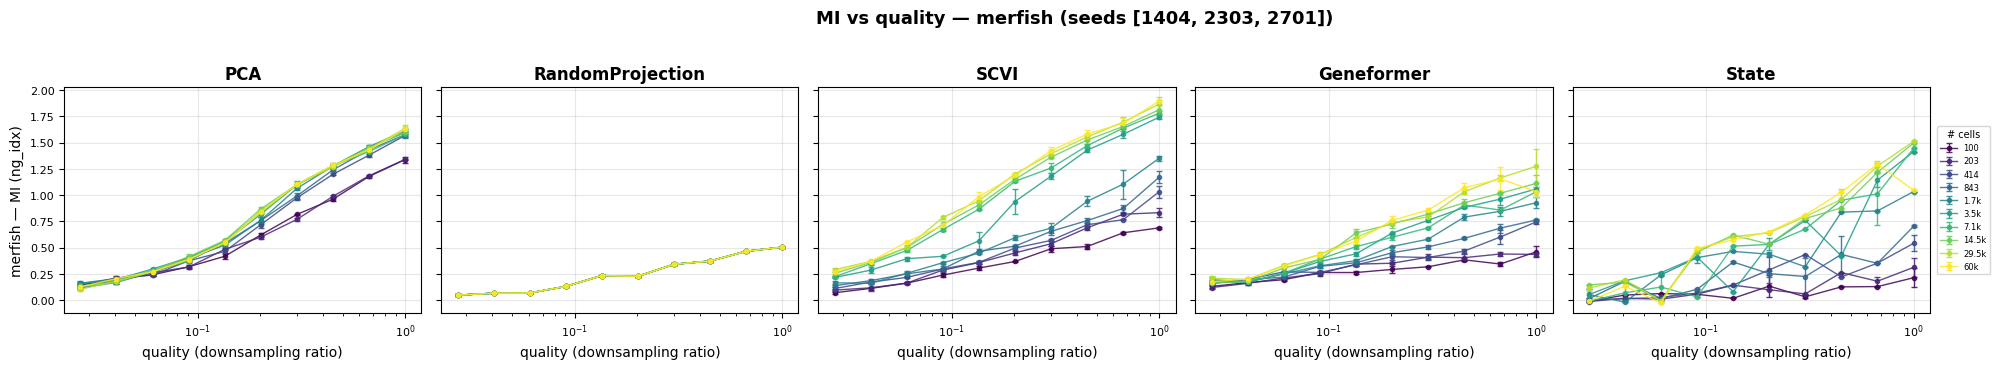

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ALGO_ORDER = ['PCA', 'RandomProjection', 'SCVI', 'Geneformer', 'State']

def _fmt_size(sz):
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

algorithms = [a for a in ALGO_ORDER if a in df_mi['algorithm'].unique()]
signals = sorted(df_mi['signal'].unique())
n_cols = len(algorithms)
n_rows = len(signals)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols + 1.6, 3.8 * n_rows),
                         squeeze=False)

# Share y within each row (per signal); each signal has its own scale.
for i in range(n_rows):
    for j in range(1, n_cols):
        axes[i, j].sharey(axes[i, 0])

cmap = plt.cm.viridis
sizes_all = sorted(df_mi['size'].unique())
norm = mcolors.LogNorm(vmin=min(sizes_all), vmax=max(sizes_all))

for i, sig in enumerate(signals):
    for j, algo in enumerate(algorithms):
        ax = axes[i, j]
        sub = df_mi[(df_mi['algorithm'] == algo) & (df_mi['signal'] == sig)]
        if sub.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)
            ax.set_xscale('log')
            continue
        for sz in sorted(sub['size'].unique()):
            color = cmap(norm(sz))
            sz_df = sub[sub['size'] == sz]
            # Aggregate across seeds for each quality.
            agg = (sz_df.groupby('quality')['mi_value']
                          .agg(['mean', 'std', 'count']).reset_index()
                          .sort_values('quality'))
            agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
            ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                        marker='o', markersize=3, linewidth=1, capsize=2,
                        color=color, alpha=0.85, label=_fmt_size(sz))
        ax.set_xscale('log')
        if i == n_rows - 1:
            ax.set_xlabel('quality (downsampling ratio)', fontsize=10)
        if i == 0:
            ax.set_title(algo, fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'merfish — MI ({sig})', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.3)
        if j > 0:
            ax.tick_params(labelleft=False)

    # One legend per row, to the right of the last column.
    handles, labels = axes[i, -1].get_legend_handles_labels()
    if handles:
        axes[i, -1].legend(handles, labels, title='# cells', fontsize=6,
                           title_fontsize=7, loc='center left',
                           bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                           frameon=True, framealpha=0.8)

fig.suptitle(f'MI vs quality — merfish (seeds {MERFISH_CFG["seeds"]})',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.02, 0.93, 0.96])
plt.show()
